## Seminário I - Cálculo Numérico | Interpolação Polinomial e Mínimos Quadrados

---

## 1. Introdução

O nosso principal problema numérico hoje é responder à seguinte pergunta: **como obter o valor de uma função para um $x$ que não foi medido durante um experimento?** A resposta depende muito da qualidade dos nossos dados e do nosso objetivo.


## Bibliotecas Utilizadas


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# configuração visual baseada no estilo do repositório
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

Matplotlib is building the font cache; this may take a moment.


## 2. Interpolação Polinomial

Quando queremos estimar o valor de $f(x)$ para um ponto intermediário que está estritamente entre duas medidas conhecidas, nós utilizamos as técnicas de interpolação. A ideia é encontrar um polinômio que passe _exatamente_ por todos os pontos que temos.

### Forma de Lagrange

A Forma de Lagrange constrói o polinômio interpolador diretamente a partir dos pontos originais.

- A fórmula genérica é dada pelo somatório:  
  **$P_n(x) = \sum_{i=0}^{n} L_i(x) \cdot f(x_i)$**

- Onde cada polinômio base $L_i(x)$ é construído para isolar o impacto de cada ponto:  
  **$L_i(x) = \frac{(x-x_0)(x-x_1)\dots(x-x_{i-1})(x-x_{i+1})\dots(x-x_n)}{(x_i-x_0)(x_i-x_1)\dots(x_i-x_{i-1})(x_i-x_{i+1})\dots(x_i-x_n)}$**


In [3]:
def interpolacao_lagrange(x, y, x_interp):
    """
    Realiza a interpolação polinomial utilizando o método de Lagrange.
    """
    n = len(x)
    is_scalar = np.isscalar(x_interp)
    if is_scalar:
        x_interp = np.array([x_interp])
        
    y_interp = np.zeros_like(x_interp, dtype=float)
    
    for i in range(n):
        L_i = np.ones_like(x_interp, dtype=float)
        for j in range(n):
            if i != j:
                L_i *= (x_interp - x[j]) / (x[i] - x[j])
        y_interp += y[i] * L_i
        
    return y_interp[0] if is_scalar else y_interp

### Forma de Newton

Para resolver a ineficiência computacional de recalcular todos os termos quando um novo ponto é adicionado, Newton utiliza o **Operador Diferenças Divididas**.

- A diferença dividida é dada por: **$f[x_0, x_1] = \frac{f(x_1) - f(x_0)}{x_1 - x_0}$**
- O polinômio é construído de forma incremental:  
  **$P_n(x) = a_0 + a_1(x-x_0) + a_2(x-x_0)(x-x_1) + \dots + a_n(x-x_0)\dots(x-x_{n-1})$**
- Os coeficientes $a_n$ correspondem aos resultados dos respectivos operadores de diferenças divididas ($a_0 = f[x_0]$, $a_1 = f[x_0, x_1]$, etc).


In [4]:
def diferencas_divididas(x, y):
    # Calcula a tabela de diferenças divididas de Newton
    n = len(y)
    tabela = np.zeros((n, n))
    tabela[:, 0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            tabela[i][j] = (tabela[i + 1][j - 1] - tabela[i][j - 1]) / (x[i + j] - x[i])
            
    return tabela[0, :] # Retorna apenas a primeira linha (os coeficientes a_n)

def interpolacao_newton(x, y, x_interp):
    # Realiza a interpolação polinomial utilizando o método de Newton
    coeficientes = diferencas_divididas(x, y)
    n = len(x)
    
    is_scalar = np.isscalar(x_interp)
    if is_scalar:
        x_interp = np.array([x_interp])
        
    y_interp = np.zeros_like(x_interp, dtype=float)
    
    for k in range(len(x_interp)):
        p = coeficientes[0]
        fator = 1.0
        for i in range(1, n):
            fator *= (x_interp[k] - x[i - 1])
            p += coeficientes[i] * fator
        y_interp[k] = p
        
    return y_interp[0] if is_scalar else y_interp

## 3. Ajuste de Curvas: Método dos Mínimos Quadrados (MMQ)

Quando os dados vêm de experimentos e contêm **erros de medição**, a interpolação polinomial falha, gerando curvas que oscilam fortemente. Para estes casos, usamos o Ajuste de Curvas.

Definimos o desvio de um ponto $P$ em relação à curva como $d_i = y_i - f(x_i)$. O Método dos Mínimos Quadrados busca encontrar uma curva que minimize o **Desvio Total** $D = \sum_{i=1}^{n} d_i^2$.

### Caso 1: A Reta ($y = ax + b$)

Para a reta, os coeficientes que minimizam o erro são dados resolvendo o sistema normal, chegando às fórmulas:
**$a = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}$** e **$b = \frac{\sum y_i - a\sum x_i}{n}$**

### Caso 2: Curva Exponencial (Redução ao Caso Linear)

Se os pontos sugerem o formato $y = be^{ax}$, não precisamos inventar nova matemática. Aplicamos o logaritmo natural de ambos os lados:
$\ln y = \ln(b e^{ax}) \Rightarrow \ln y = \ln b + ax$

Fazendo as mudanças de variáveis **$Y = \ln y$** e **$B = \ln b$**, obtemos a reta **$Y = ax + B$**. Após encontrar $B$, basta fazer $b = e^B$.


In [5]:
def minimos_quadrados_reta(x, y):
    """
    Ajusta uma reta y = ax + b aos pontos (x, y) usando Mínimos Quadrados.
    """
    n = len(x)
    soma_x = np.sum(x)
    soma_y = np.sum(y)
    soma_x2 = np.sum(x**2)
    soma_xy = np.sum(x * y)
    
    A = np.array([[n, soma_x], [soma_x, soma_x2]])
    B = np.array([soma_y, soma_xy])
    
    coefs = np.linalg.solve(A, B)
    b, a = coefs[0], coefs[1]
    
    return a, b

def minimos_quadrados_exponencial(x, y):
    """
    Ajusta a curva y = b * e^(ax) fazendo a linearização Y = ln(y).
    """
    # Redução ao caso linear: Y = ln(y)
    Y = np.log(y)
    
    # Usa a função da reta para achar 'a' e 'B'
    a, B = minimos_quadrados_reta(x, Y)
    
    # Recupera o 'b' original
    b = np.exp(B)
    
    return a, b

## 4. Estudo de Caso Numérico

Vamos testar nossos algoritmos com exemplos numéricos diferentes e comparar o comportamento de interpolação e ajustes de curva.


In [6]:
# Exemplo de interpolação
x_ex1 = np.array([0.0, 2.0, 3.5])
y_ex1 = np.array([1.0, 2.8, 3.7])
print("--- Exemplo Interpolação ---")
print(f"P(1.5) interpolado via Lagrange: {interpolacao_lagrange(x_ex1, y_ex1, 1.5):.4f}")
print(f"P(1.5) interpolado via Newton:   {interpolacao_newton(x_ex1, y_ex1, 1.5):.4f}")
print("Polinômio resultante aproximado com os dados acima.\n")

# Exemplo de MMQ reta
x_ex2 = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_ex2 = np.array([1.1, 2.0, 2.9, 4.2, 5.1])
a_reta, b_reta = minimos_quadrados_reta(x_ex2, y_ex2)
print("--- Exemplo MMQ Reta ---")
print(f"Equação encontrada: y = {a_reta:.2f}x + {b_reta:.2f}")
print("Este ajuste mostra a tendência linear dos dados.\n")

# Exemplo de MMQ exponencial
x_ex3 = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
y_ex3 = np.array([1.0, 1.8, 3.2, 5.6, 8.7])
a_exp, b_exp = minimos_quadrados_exponencial(x_ex3, y_ex3)
print("--- Exemplo MMQ Exponencial ---")
print(f"Equação encontrada: y = {b_exp:.4f} * e^({a_exp:.4f}x)")
print("Este ajuste mostra como dados de crescimento exponencial podem ser tratados.\n")

--- Exemplo Interpolação ---
P(1.5) interpolado via Lagrange: 2.4143
P(1.5) interpolado via Newton:   2.4143
Polinômio resultante aproximado com os dados acima.

--- Exemplo MMQ Reta ---
Equação encontrada: y = 1.02x + 1.02
Este ajuste mostra a tendência linear dos dados.

--- Exemplo MMQ Exponencial ---
Equação encontrada: y = 1.0357 * e^(1.0923x)
Este ajuste mostra como dados de crescimento exponencial podem ser tratados.



## 5. Prática Final: O Fenômeno Visual

Vamos testar a diferença visual entre forçar um polinômio interpolador e encontrar o Ajuste de Mínimos Quadrados em um conjunto de pontos com **ruído experimental**.


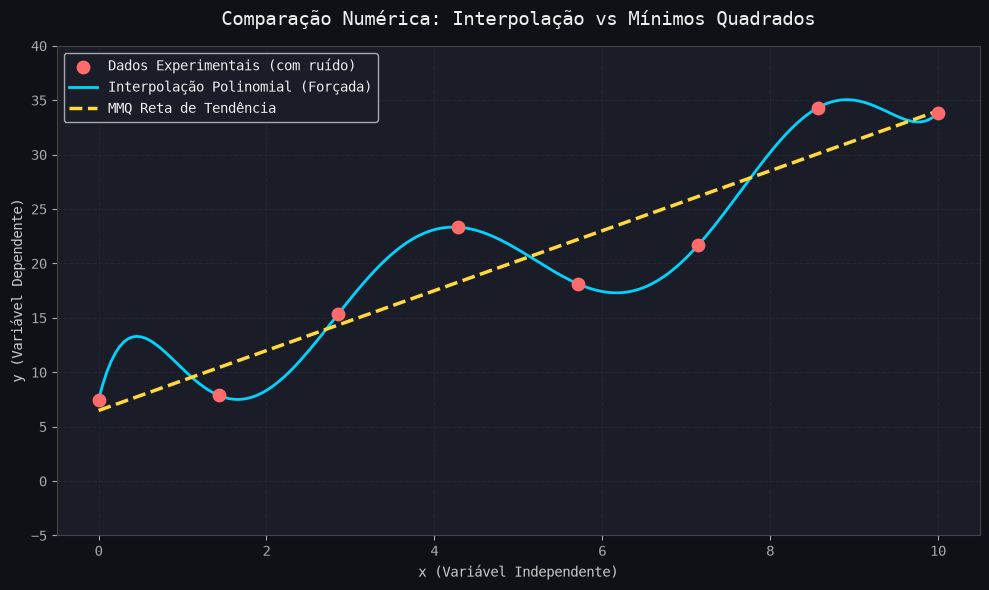

In [7]:
# Gerando dados experimentais ruidosos
np.random.seed(42)
x_dados = np.linspace(0, 10, 8)
y_real = 2.5 * x_dados + 5.0
y_ruidoso = y_real + np.random.normal(0, 5, len(x_dados))

# Dominio contínuo para as curvas
x_plot = np.linspace(0, 10, 200)

y_interp = interpolacao_lagrange(x_dados, y_ruidoso, x_plot)
a_mmq, b_mmq = minimos_quadrados_reta(x_dados, y_ruidoso)
y_mmq = a_mmq * x_plot + b_mmq

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_dados, y_ruidoso, color='#ff6b6b', s=80, zorder=5, label='Dados Experimentais (com ruído)')
ax.plot(x_plot, y_interp, color='#00d4ff', lw=2, label='Interpolação Polinomial (Forçada)')
ax.plot(x_plot, y_mmq, color='#ffd93d', lw=2.5, ls='--', label=f'MMQ Reta de Tendência')

ax.set_ylim([-5, 40]) # limitando para focar no desvio
ax.set_title('Comparação Numérica: Interpolação vs Mínimos Quadrados', fontsize=14, pad=15)
ax.set_xlabel('x (Variável Independente)')
ax.set_ylabel('y (Variável Dependente)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

## Conclusão

- Use **Lagrange ou Newton** quando seus dados forem perfeitamente confiáveis e você precisar de precisão cirúrgica em valores intermediários.
- Use o **Método dos Mínimos Quadrados** para dados experimentais, extrair o sinal do ruído e calcular a tendência reduzindo o Desvio Total ($D$).

---

**Muito obrigada pela atenção!**
